In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def summarize_series(series: pd.Series) -> dict:
    if len(series) == 0:
        raise ValueError("빈 값")
    #시작/끝·관측 행 수·결측값 수·누락 연도 목록·중복 여부. 숫자 요약을 내면 그 값이 어느 기간의 것인지 명시한다.
    #복사
    copy = series.copy()
    #시작 끝
    start = [copy.iloc[[0]].index[0],copy.iloc[0]]
    end = [copy.iloc[[-1]].index[0],copy.iloc[-1]]
    #관측 행 수 
    row = len(series)
    #결측값 수
    nan = copy.isnull().sum()
    #누락 연도 목록
    year_excluded = []
    y_start = copy.iloc[[0]].index[0]
    y_end = copy.iloc[[-1]].index[0]

    for i in range(y_start.year  , y_end.year  ):
        
        if i not in copy.index.year:
            year_excluded.append(i)

    #중복 여부
    duplicate = copy.index.duplicated().any()
    #숫자요약?
    valid = copy.dropna()
    if valid.empty:
        mean = None
        min_value = None
        max_value = None
    else:
        mean = valid.mean()
        min_value = [valid.idxmin(), valid.min()]
        max_value = [valid.idxmax(), valid.max()]
    result = {'시작':start, "끝": end, '관측 행 수' : row, '결측값 수': nan,'누락 연도':year_excluded ,"중복 유무": duplicate, 
              'mean':mean, 'max':max_value,'min':min_value}
    result["요약 기간"] = {
        "시작": y_start,
        "끝": y_end,
        "결측 처리": "결측값 제외",
        "유효 관측 수": len(valid),
    }
    #기본 데이터에서 관측값 결측·누락이 없음을 실제로 확인한다. 있으면 모델링을 멈추고 원인과 처리 정책부터 기록한다.
    return result

In [3]:
def generate_ts_report(series: pd.Series, output_dir: str, label: str) -> str:
    """
    요구사항:
    - series : 인덱스가 연도인 연간 단변량 관측값. 정렬·연속·중복없음·결측없음이 확인된 것.
    - output_dir : 이번 실행 전용 새 폴더. 없으면 이 함수가 만든다. 기존 폴더를 덮어쓰지 않는다.
    - label : 사람이 읽을 기간 제목. 데이터를 자르지 않는다.
    - 반환 : 생성한 report.md 의 경로 문자열.
    - report.md 에 들어갈 것: 기간·빈도·행 수·누락 시점 수·결측값 수,
      위 그림 두 개의 링크(보고서 위치 기준 상대 경로), 해석을 쓸 빈 자리.

    예시: 2000~2003년 [10,15,12,18], "reports/example_run_01", "가상 학습 구간"
          -> "reports/example_run_01/report.md", 보고서에 4행·누락 0·결측 0과 그림 링크 2개
    """

    folder_path = output_dir
    os.makedirs(folder_path, exist_ok = True)
    
    #라벨 편집
    start, end = pd.Period(int(label[:4]),freq="Y"), pd.Period(int(label[-4:]),freq="Y")
    summary = summarize_series(series.loc[start:end])
    content = {"기간":[summary["시작"], summary["끝"]], "행수":summary["관측 행 수"], "누락":summary["누락 연도"], "결측":summary["결측값 수"]}
    with open(f"{folder_path}/report.md","w", encoding='utf-8') as f:
        f.write(f"{label}\n{series[start:end].values}\n{content["행수"]}행, 누락 {len(content["누락"])}, 결측 {content["결측"]}")
    result = []

    for j in range(start.year, end.year):
        
        i = pd.Period(j,freq="Y")
        if i.year >= 4 :
            avg = (series.loc[i]+series.loc[i-1]+series.loc[i-2]+series.loc[i-3]+series.loc[i-4])/5
            result.append(avg)


    plt.figure()
    plt.plot(series.loc[start+1:end].index.year,result, label='5년 이동평균선')
    plt.xlabel("year")
    plt.ylabel("SUNACTIVITY")
    plt.plot(series.loc[start:end].index.year, series.loc[start:end].values, label='원본')
    plt.legend()
    plt.savefig("series.png")
    plt.show()
    

C:\Users\AIT-E USER\AppData\Local\Temp\ipykernel_36976\362069565.py:40: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) DejaVu Sans.
  plt.savefig("series.png")
C:\Users\AIT-E USER\AppData\Local\Temp\ipykernel_36976\362069565.py:40: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.savefig("series.png")
C:\Users\AIT-E USER\AppData\Local\Temp\ipykernel_36976\362069565.py:40: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.savefig("series.png")
C:\Users\AIT-E USER\AppData\Local\Temp\ipykernel_36976\362069565.py:40: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.savefig("series.png")
C:\Users\AIT-E USER\AppData\Local\Temp\ipykernel_36976\362069565.py:40: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.savefig("series.png")
C:\Users\AIT-E USER\AppData\Local\Temp\ipykernel_36976\362069565.py:40

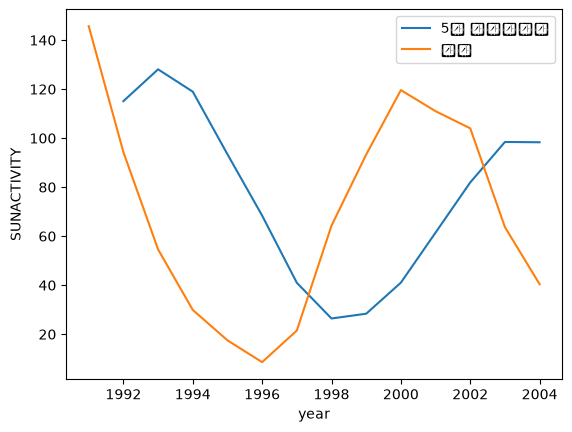

In [4]:
df = pd.read_csv("output.csv", index_col=0)
df.index = pd.PeriodIndex(df.index, freq="Y")
generate_ts_report(df["target"], "eda","1991 ~ 2004")